<a href="https://colab.research.google.com/github/Vixtoe/LAPD_Crime_Analytics/blob/main/01_eda_and_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv('/crime_cleaned.csv')
print(df.shape)
df.head()

(1004991, 28)


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,occ_year,occ_month,occ_date,occ_day
0,211507896,2021-04-11,2020-11-07,08:45:00,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,7800 BEEMAN AV,34.2124,-118.4092,2020,Nov,7,Sat
1,201516622,2020-10-21,2020-10-18,18:45:00,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,ATOLL AV,34.1993,-118.4203,2020,Oct,18,Sun
2,240913563,2024-12-10,2020-10-30,12:40:00,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,14600 SYLVAN ST,34.1847,-118.4509,2020,Oct,30,Fri
3,210704711,2020-12-24,2020-12-24,13:10:00,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,6000 COMEY AV,34.0339,-118.3747,2020,Dec,24,Thu
4,201418201,2020-10-03,2020-09-29,18:30:00,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,4700 LA VILLA MARINA,33.9813,-118.4350,2020,Sep,29,Tue


In [31]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

In [32]:
# Crime count by area, sorted highest to lowest
df['AREA NAME'].value_counts().head(10)

,count
AREA NAME,
Central,69670
77th Street,61758
Pacific,59514
Southwest,57441
Hollywood,52429
N Hollywood,51107
Olympic,50071
Southeast,49936
Newton,49177


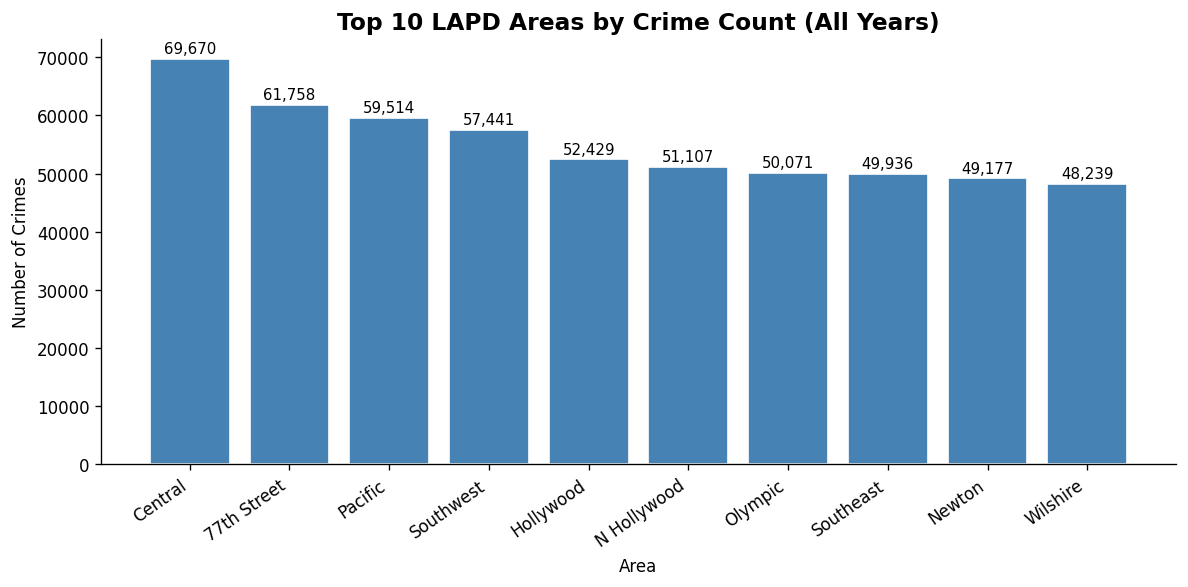

In [33]:
# Top 10 areas by total crime count
area_counts = df['AREA NAME'].value_counts().head(10)

plt.figure(figsize=(10, 5))
bars = plt.bar(area_counts.index, area_counts.values, color='steelblue', edgecolor='white')
plt.title('Top 10 LAPD Areas by Crime Count (All Years)', fontsize=14, fontweight='bold')
plt.xlabel('Area')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=35, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
# Pad to 4 digits and slice the hour
df['hour'] = df['TIME OCC'].astype(str).str.zfill(4).str[:2].astype(int)

# Crime count by hour
df['hour'].value_counts().sort_index()

,count
hour,
0,40468
1,29761
2,25214
3,22191
4,18757
5,17290
6,23185
7,26267
8,37249


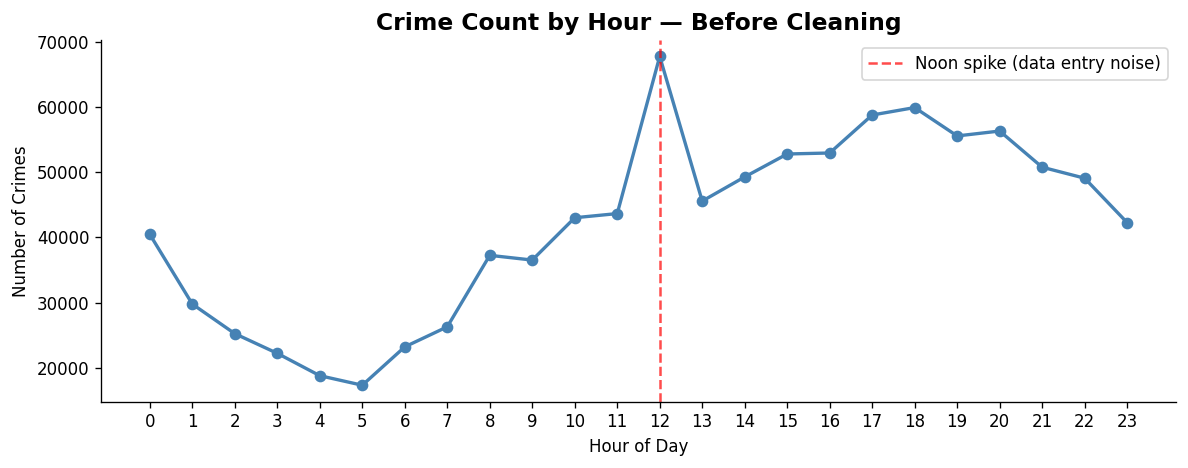

Notice the spike at noon — caused by identity theft logged with default 12:00 time


In [35]:
# Crime count by hour — BEFORE removing non-physical crimes
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(hour_counts.index, hour_counts.values, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=12, color='red', linestyle='--', alpha=0.7, label='Noon spike (data entry noise)')
plt.title('Crime Count by Hour — Before Cleaning', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()
print('Notice the spike at noon — caused by identity theft logged with default 12:00 time')

In [36]:
# Crime count by area and hour
area_hour = df.groupby(['AREA NAME', 'hour']).size().reset_index(name='crime_count')

# For each area, show the peak hour
area_hour.loc[area_hour.groupby('AREA NAME')['crime_count'].idxmax()].sort_values('crime_count', ascending=False).head(10)

,AREA NAME,hour,crime_count
300,Pacific,12,4294
42,Central,18,4188
12,77th Street,12,3899
372,Southwest,12,3661
492,Wilshire,12,3566
204,N Hollywood,12,3560
396,Topanga,12,3488
156,Hollywood,12,3399
420,Van Nuys,12,3316
60,Devonshire,12,3271


In [37]:
# What crimes happen at noon in Pacific?
df[(df['AREA NAME'] == 'Pacific') & (df['hour'] == 12)]['Crm Cd Desc'].value_counts().head(10)

,count
Crm Cd Desc,
THEFT OF IDENTITY,504
THEFT PLAIN - PETTY ($950 & UNDER),421
VEHICLE - STOLEN,322
"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD",316
BURGLARY,275
"EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)",241
BATTERY - SIMPLE ASSAULT,216
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),206
BURGLARY FROM VEHICLE,193


In [38]:
# Get all unique crime types to identify non-physical ones
df['Crm Cd Desc'].value_counts()

,count
Crm Cd Desc,
VEHICLE - STOLEN,115190
BATTERY - SIMPLE ASSAULT,74839
BURGLARY FROM VEHICLE,63517
THEFT OF IDENTITY,62537
"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",61092
...,...
FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO),5
FIREARMS RESTRAINING ORDER (FIREARMS RO),4
DISHONEST EMPLOYEE ATTEMPTED THEFT,4


In [39]:
# Print all crime types without truncation
for crime in sorted(df['Crm Cd Desc'].unique()):
    print(crime)

ARSON
ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT
ATTEMPTED ROBBERY
BATTERY - SIMPLE ASSAULT
BATTERY ON A FIREFIGHTER
BATTERY POLICE (SIMPLE)
BATTERY WITH SEXUAL CONTACT
BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM
BIGAMY
BIKE - ATTEMPTED STOLEN
BIKE - STOLEN
BLOCKING DOOR INDUCTION CENTER
BOAT - STOLEN
BOMB SCARE
BRANDISH WEAPON
BRIBERY
BUNCO, ATTEMPT
BUNCO, GRAND THEFT
BUNCO, PETTY THEFT
BURGLARY
BURGLARY FROM VEHICLE
BURGLARY FROM VEHICLE, ATTEMPTED
BURGLARY, ATTEMPTED
CHILD ABANDONMENT
CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT
CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT
CHILD ANNOYING (17YRS & UNDER)
CHILD NEGLECT (SEE 300 W.I.C.)
CHILD PORNOGRAPHY
CHILD STEALING
CONSPIRACY
CONTEMPT OF COURT
CONTRIBUTING
COUNTERFEIT
CREDIT CARDS, FRAUD USE ($950 & UNDER
CREDIT CARDS, FRAUD USE ($950.01 & OVER)
CRIMINAL HOMICIDE
CRIMINAL THREATS - NO WEAPON DISPLAYED
CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)
CRUELTY TO ANIMALS


In [40]:
# Crimes with no physical scene — location/time data is unreliable for patrol modeling
no_scene_crimes = [
    'THEFT OF IDENTITY',
    'COUNTERFEIT',
    'CREDIT CARDS, FRAUD USE ($950 & UNDER',
    'CREDIT CARDS, FRAUD USE ($950.01 & OVER)',
    'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)',
    'EMBEZZLEMENT, PETTY THEFT ($950 & UNDER)',
    'DOCUMENT FORGERY / STOLEN FELONY',
    'DOCUMENT WORTHLESS ($200 & UNDER)',
    'DOCUMENT WORTHLESS ($200.01 & OVER)',
    'GRAND THEFT / INSURANCE FRAUD',
    'UNAUTHORIZED COMPUTER ACCESS',
    'BUNCO, ATTEMPT',
    'BUNCO, GRAND THEFT',
    'BUNCO, PETTY THEFT',
    'DISHONEST EMPLOYEE - GRAND THEFT',
    'DISHONEST EMPLOYEE - PETTY THEFT',
    'DISHONEST EMPLOYEE ATTEMPTED THEFT',
    'FALSE POLICE REPORT',
    'BRIBERY',
    'CONSPIRACY',
    'CONTEMPT OF COURT',
    'VIOLATION OF COURT ORDER',
    'VIOLATION OF RESTRAINING ORDER',
    'VIOLATION OF TEMPORARY RESTRAINING ORDER',
    'SEX OFFENDER REGISTRANT OUT OF COMPLIANCE',
    'FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)',
    'FIREARMS RESTRAINING ORDER (FIREARMS RO)',
    'CONTRIBUTING',
]

df_physical = df[~df['Crm Cd Desc'].isin(no_scene_crimes)].copy()

print('Original:', len(df))
print('Physical only:', len(df_physical))
print('Dropped:', len(df) - len(df_physical))

Original: 1004991
Physical only: 902193
Dropped: 102798


In [41]:
df_physical.to_csv(r'C:\Users\apivi\Desktop\1\crime_physical.csv', index=False)

In [42]:
# Check if noon spike is cleaner now
df_physical['hour'].value_counts().sort_index()

,count
hour,
0,32413
1,27542
2,23995
3,21217
4,17886
5,16216
6,18692
7,22698
8,30728


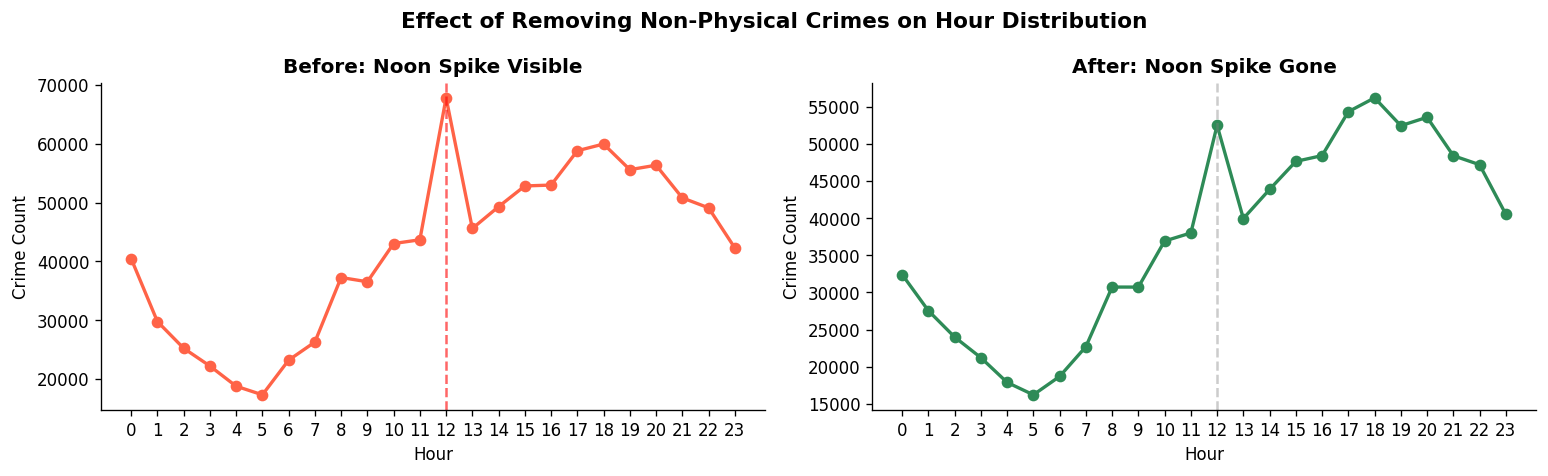

In [43]:
# Before vs After removing non-physical crimes — noon spike comparison
hour_before = df['hour'].value_counts().sort_index()
hour_after  = df_physical['hour'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hour_before.index, hour_before.values, marker='o', color='tomato', linewidth=2)
axes[0].axvline(x=12, color='red', linestyle='--', alpha=0.6)
axes[0].set_title('Before: Noon Spike Visible', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Crime Count')
axes[0].set_xticks(range(0, 24))

axes[1].plot(hour_after.index, hour_after.values, marker='o', color='seagreen', linewidth=2)
axes[1].axvline(x=12, color='gray', linestyle='--', alpha=0.4)
axes[1].set_title('After: Noon Spike Gone', fontweight='bold')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Crime Count')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Effect of Removing Non-Physical Crimes on Hour Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
df_physical['DATE OCC'] = pd.to_datetime(df_physical['DATE OCC'])

In [45]:
# Feature engineering from date
df_physical['day_of_week'] = df_physical['DATE OCC'].dt.dayofweek  # 0=Monday, 6=Sunday
df_physical['month'] = df_physical['DATE OCC'].dt.month
df_physical['year'] = df_physical['DATE OCC'].dt.year
df_physical['is_weekend'] = (df_physical['day_of_week'] >= 5).astype(int)

df_physical[['DATE OCC', 'hour', 'day_of_week', 'month', 'year', 'is_weekend']].head(10)

,DATE OCC,hour,day_of_week,month,year,is_weekend
1,2020-10-18,18,6,10,2020,1
3,2020-12-24,13,3,12,2020,0
4,2020-09-29,18,1,9,2020,0
7,2020-07-07,14,1,7,2020,0
10,2020-06-20,0,5,6,2020,1
12,2020-09-05,15,5,9,2020,1
13,2020-07-02,5,3,7,2020,0
14,2020-02-13,23,3,2,2020,0
15,2020-02-01,16,5,2,2020,1
16,2020-11-08,7,6,11,2020,1


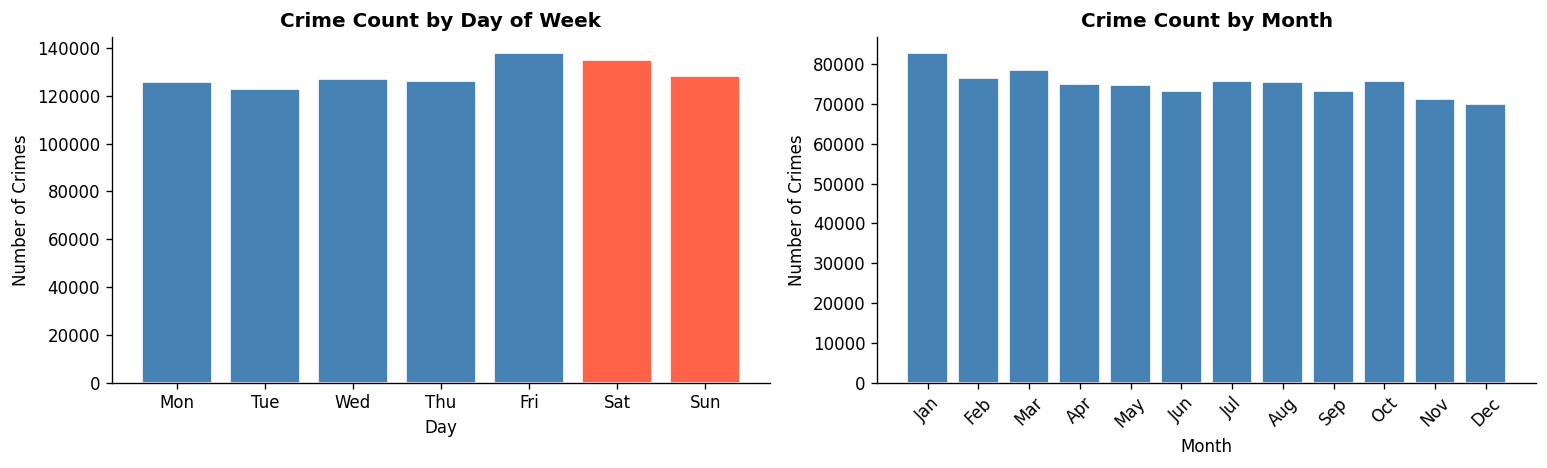

Weekends (red) slightly lower — people are at home or routines change


In [46]:
# Crime patterns by day of week and month
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Day of week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df_physical['day_of_week'].value_counts().sort_index()
colors_dow = ['steelblue' if i < 5 else 'tomato' for i in range(7)]
axes[0].bar(day_labels, dow_counts.values, color=colors_dow, edgecolor='white')
axes[0].set_title('Crime Count by Day of Week', fontweight='bold')
axes[0].set_ylabel('Number of Crimes')
axes[0].set_xlabel('Day')

# Month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_counts = df_physical['month'].value_counts().sort_index()
axes[1].bar(month_labels, month_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Crime Count by Month', fontweight='bold')
axes[1].set_ylabel('Number of Crimes')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('Weekends (red) slightly lower — people are at home or routines change')

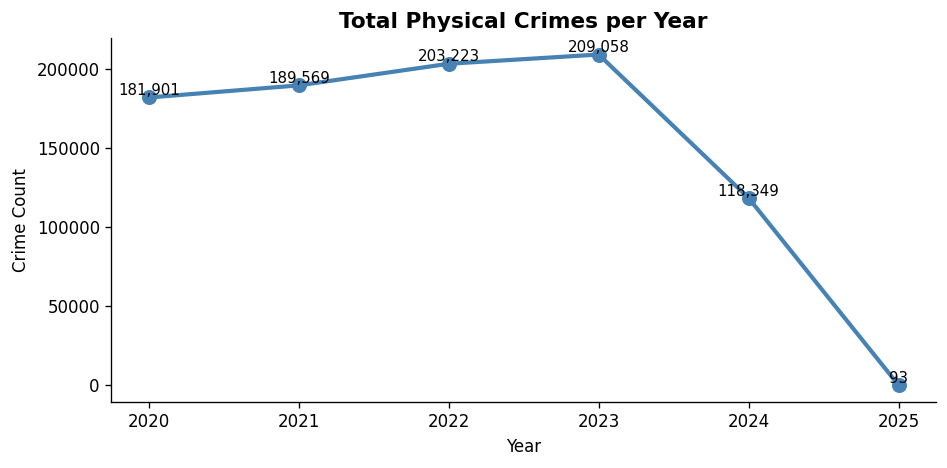

Note: 2024-2025 are incomplete years — lower count does not mean lower crime


In [47]:
# Yearly crime trend — are patterns changing over time?
yearly = df_physical.groupby('year').size().reset_index(name='crime_count')

plt.figure(figsize=(8, 4))
plt.plot(yearly['year'], yearly['crime_count'], marker='o', color='steelblue',
         linewidth=2.5, markersize=8)
for _, row in yearly.iterrows():
    plt.text(row['year'], row['crime_count'] + 1500, f"{row['crime_count']:,}",
             ha='center', fontsize=9)
plt.title('Total Physical Crimes per Year', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Crime Count')
plt.xticks(yearly['year'])
plt.tight_layout()
plt.show()
print('Note: 2024-2025 are incomplete years — lower count does not mean lower crime')

In [48]:
# Build target: crime count per area per day per hour
target = df_physical.groupby(['AREA NAME', 'year', 'month', 'day_of_week', 'hour']).size().reset_index(name='crime_count')

print(target.shape)
target.head(10)

(197071, 6)


,AREA NAME,year,month,day_of_week,hour,crime_count
0,77th Street,2020,1,0,0,4
1,77th Street,2020,1,0,1,3
2,77th Street,2020,1,0,2,2
3,77th Street,2020,1,0,3,5
4,77th Street,2020,1,0,4,3
5,77th Street,2020,1,0,5,3
6,77th Street,2020,1,0,6,3
7,77th Street,2020,1,0,7,4
8,77th Street,2020,1,0,8,7
9,77th Street,2020,1,0,9,5


In [49]:
# Encode AREA NAME as numbers
target['area_code'] = target['AREA NAME'].astype('category').cat.codes

# Check the mapping
area_mapping = dict(enumerate(target['AREA NAME'].astype('category').cat.categories))
print(area_mapping)

{0: '77th Street', 1: 'Central', 2: 'Devonshire', 3: 'Foothill', 4: 'Harbor', 5: 'Hollenbeck', 6: 'Hollywood', 7: 'Mission', 8: 'N Hollywood', 9: 'Newton', 10: 'Northeast', 11: 'Olympic', 12: 'Pacific', 13: 'Rampart', 14: 'Southeast', 15: 'Southwest', 16: 'Topanga', 17: 'Van Nuys', 18: 'West LA', 19: 'West Valley', 20: 'Wilshire'}


In [50]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

X = target[['area_code', 'year', 'month', 'day_of_week', 'hour']]
y = target['crime_count']

models = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=3, scoring='neg_mean_absolute_error')
    mae = -scores.mean()
    print(f'{name}: MAE = {mae:.2f}')

Linear Regression: MAE = 2.14
Gradient Boosting: MAE = 1.94
Random Forest: MAE = 2.17


In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(xgb, X, y, cv=3, scoring='neg_mean_absolute_error')
print(f'XGBoost MAE = {-scores.mean():.2f}')

XGBoost MAE = 1.92


In [52]:
print(target['crime_count'].describe())

count    197071.000000
mean          4.578010
std           3.001213
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          53.000000
Name: crime_count, dtype: float64


In [53]:
# Group hours into 4 buckets
# 0-5: Night, 6-11: Morning, 12-17: Afternoon, 18-23: Evening
def hour_to_bucket(h):
    if h < 6:   return 0  # Night
    if h < 12:  return 1  # Morning
    if h < 18:  return 2  # Afternoon
    return 3               # Evening

target['hour_bucket'] = target['hour'].apply(hour_to_bucket)

# Regroup by area + year + month + day_of_week + hour_bucket
target2 = target.groupby(['AREA NAME', 'area_code', 'year', 'month', 'day_of_week', 'hour_bucket'])['crime_count'].sum().reset_index()

print(target2.shape)
target2.head()

(35345, 7)


,AREA NAME,area_code,year,month,day_of_week,hour_bucket,crime_count
0,77th Street,0,2020,1,0,0,20
1,77th Street,0,2020,1,0,1,29
2,77th Street,0,2020,1,0,2,58
3,77th Street,0,2020,1,0,3,65
4,77th Street,0,2020,1,1,0,28


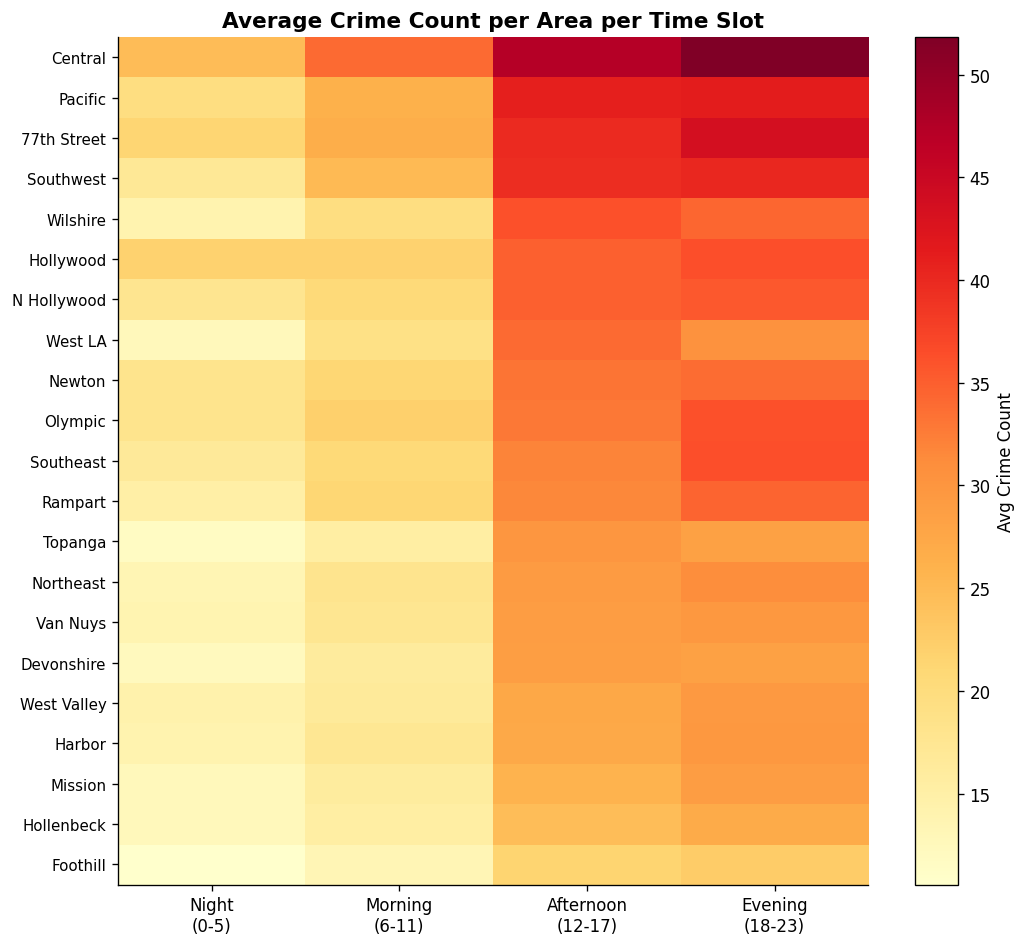

In [54]:
# Heatmap: average crime count per area per hour bucket
import numpy as np

bucket_labels = ['Night\n(0-5)', 'Morning\n(6-11)', 'Afternoon\n(12-17)', 'Evening\n(18-23)']

pivot = target2.pivot_table(
    index='AREA NAME', columns='hour_bucket', values='crime_count', aggfunc='mean'
)
pivot = pivot.sort_values(by=2, ascending=False)  # sort by afternoon

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Avg Crime Count')
ax.set_xticks(range(4))
ax.set_xticklabels(bucket_labels)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title('Average Crime Count per Area per Time Slot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
X2 = target2[['area_code', 'year', 'month', 'day_of_week', 'hour_bucket']]
y2 = target2['crime_count']

for name, model in models.items():
    scores = cross_val_score(model, X2, y2, cv=3, scoring='neg_mean_absolute_error')
    print(f'{name}: MAE = {-scores.mean():.2f}')

# XGBoost too
xgb2 = XGBRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(xgb2, X2, y2, cv=3, scoring='neg_mean_absolute_error')
print(f'XGBoost: MAE = {-scores.mean():.2f}')

Linear Regression: MAE = 8.39
Gradient Boosting: MAE = 7.24
Random Forest: MAE = 7.88
XGBoost: MAE = 7.36


In [56]:
print(target2['crime_count'].describe())
print()
# Error as % of mean
mean = target2['crime_count'].mean()
print(f'Gradient Boosting error %: {7.23/mean*100:.1f}%')
print(f'Previous error % (hourly): {1.93/4.57*100:.1f}%')

count    35345.000000
mean        25.525336
std         13.484937
min          1.000000
25%         15.000000
50%         24.000000
75%         34.000000
max        200.000000
Name: crime_count, dtype: float64

Gradient Boosting error %: 28.3%
Previous error % (hourly): 42.2%


In [57]:
# 1. Target encoding: replace area_code with area's mean crime count
area_mean = target2.groupby('AREA NAME')['crime_count'].mean()
target2['area_mean_crime'] = target2['AREA NAME'].map(area_mean)

# 2. Add is_weekend
target2['is_weekend'] = (target2['day_of_week'] >= 5).astype(int)

X3 = target2[['area_mean_crime', 'year', 'month', 'day_of_week', 'hour_bucket', 'is_weekend']]
y3 = target2['crime_count']

for name, model in models.items():
    scores = cross_val_score(model, X3, y3, cv=3, scoring='neg_mean_absolute_error')
    print(f'{name}: MAE = {-scores.mean():.2f} ({-scores.mean()/target2["crime_count"].mean()*100:.1f}%)')

xgb3 = XGBRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(xgb3, X3, y3, cv=3, scoring='neg_mean_absolute_error')
print(f'XGBoost: MAE = {-scores.mean():.2f} ({-scores.mean()/target2["crime_count"].mean()*100:.1f}%)')

Linear Regression: MAE = 7.46 (29.2%)
Gradient Boosting: MAE = 5.86 (22.9%)
Random Forest: MAE = 6.17 (24.2%)
XGBoost: MAE = 5.56 (21.8%)


In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
}

xgb_tune = XGBRegressor(random_state=42)
grid_search = GridSearchCV(xgb_tune, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X3, y3)

best_mae = -grid_search.best_score_
print(f'Best params: {grid_search.best_params_}')
print(f'Best MAE: {best_mae:.2f} ({best_mae/target2["crime_count"].mean()*100:.1f}%)')

Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300}
Best MAE: 5.51 (21.6%)


In [62]:
# Load clean weather data
weather_clean = pd.read_csv(r'/weather_clean.csv')
weather_clean['DATE'] = pd.to_datetime(weather_clean['DATE'])

# Add exact date column to df_physical for merging
df_physical['DATE OCC'] = pd.to_datetime(df_physical['DATE OCC'])
df_physical['date'] = pd.to_datetime(df_physical['DATE OCC'].dt.date.astype(str))

# Merge crime with weather on date
crime_weather = df_physical.merge(
    weather_clean,
    left_on='date',
    right_on='DATE',
    how='left'
)

print('Before merge:', len(df_physical))
print('After merge:', len(crime_weather))
print('Weather nulls after merge:', crime_weather['TMAX'].isnull().sum())

Before merge: 902193
After merge: 902193
Weather nulls after merge: 0


In [63]:
# Add hour_bucket to crime_weather
crime_weather['hour_bucket'] = crime_weather['hour'].apply(hour_to_bucket)

# Aggregate: crime count + weather per area per time slot
target3 = crime_weather.groupby(['AREA NAME', 'year', 'month', 'day_of_week', 'hour_bucket']).agg(
    crime_count=('Crm Cd', 'count'),
    TMAX=('TMAX', 'mean'),
    TMIN=('TMIN', 'mean'),
    PRCP=('PRCP', 'mean'),
    is_rainy=('is_rainy', 'max'),
    is_hot=('is_hot', 'max'),
    WT01=('WT01', 'max'),
    WT03=('WT03', 'max'),
    WT08=('WT08', 'max'),
).reset_index()

# Target encoding — use training years only to avoid leakage from incomplete 2024-2025
area_mean3 = target3[target3['year'] <= 2022].groupby('AREA NAME')['crime_count'].mean()
target3['area_mean_crime'] = target3['AREA NAME'].map(area_mean3)
target3['is_weekend'] = (target3['day_of_week'] >= 5).astype(int)

print(target3.shape)
target3.head()

(35345, 16)


,AREA NAME,year,month,day_of_week,hour_bucket,crime_count,TMAX,TMIN,PRCP,is_rainy,is_hot,WT01,WT03,WT08,area_mean_crime,is_weekend
0,77th Street,2020,1,0,0,20,67.800000,51.400000,0.008000,1,0,1,0,1,36.16369,0
1,77th Street,2020,1,0,1,29,65.413793,51.241379,0.006207,1,0,1,0,1,36.16369,0
2,77th Street,2020,1,0,2,58,68.000000,50.844828,0.005862,1,0,1,0,1,36.16369,0
3,77th Street,2020,1,0,3,65,70.092308,49.984615,0.004000,1,0,1,0,1,36.16369,0
4,77th Street,2020,1,1,0,28,69.214286,53.642857,0.007500,1,0,0,0,1,36.16369,0


In [64]:
# XGBoost with weather features (cross-validation)
X_w = target3[['area_mean_crime', 'year', 'month', 'day_of_week', 'hour_bucket', 'is_weekend',
               'TMAX', 'TMIN', 'PRCP', 'is_rainy', 'is_hot', 'WT01', 'WT03', 'WT08']]
y_w = target3['crime_count']

xgb4 = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
scores = cross_val_score(xgb4, X_w, y_w, cv=3, scoring='neg_mean_absolute_error')
print(f'XGBoost with weather: MAE = {-scores.mean():.2f} ({-scores.mean()/target3["crime_count"].mean()*100:.1f}%)')

XGBoost with weather: MAE = 5.61 (22.0%)


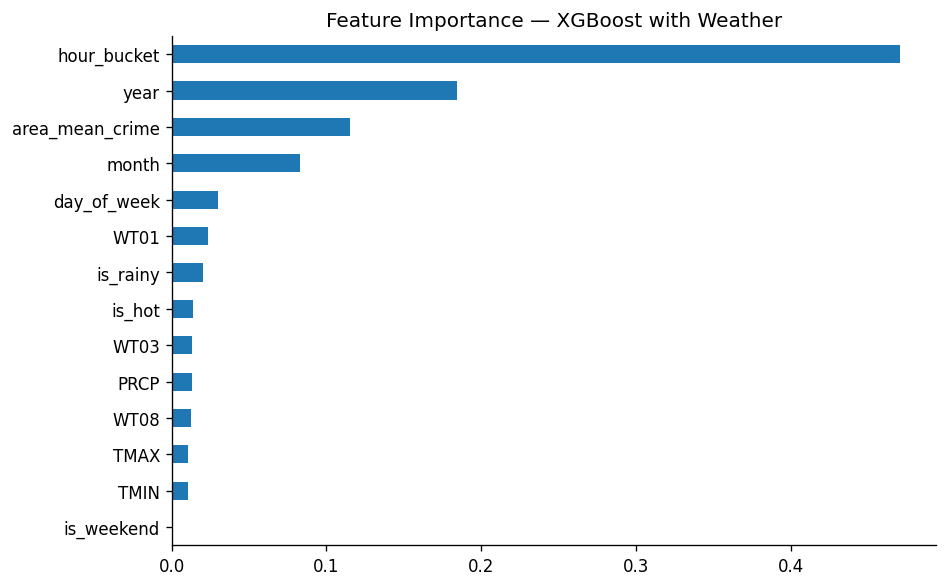

In [65]:
import matplotlib.pyplot as plt

# Fit on full data to get feature importances
xgb4.fit(X_w, y_w)

feat_imp = pd.Series(xgb4.feature_importances_, index=X_w.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh')
plt.title('Feature Importance — XGBoost with Weather')
plt.tight_layout()
plt.show()

In [66]:
# Time-based train/test split — more honest than cross-val for future prediction
# Train on 2020-2022, test on 2023, no year feature

features_no_year = ['area_mean_crime', 'month', 'day_of_week', 'hour_bucket', 'is_weekend',
                    'TMAX', 'TMIN', 'PRCP', 'is_rainy', 'is_hot', 'WT01', 'WT03', 'WT08']

train3 = target3[target3['year'] <= 2022]
test3  = target3[target3['year'] == 2023]

xgb6 = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb6.fit(train3[features_no_year], train3['crime_count'])

from sklearn.metrics import mean_absolute_error
preds6 = xgb6.predict(test3[features_no_year])
mae6 = mean_absolute_error(test3['crime_count'], preds6)
test3_mean = test3['crime_count'].mean()
print(f'Time-based MAE (no year): {mae6:.2f} ({mae6/test3_mean*100:.1f}% of 2023 mean)')
print(f'2023 test mean crime count: {test3_mean:.1f}')

Time-based MAE (no year): 6.70 (22.6% of 2023 mean)
2023 test mean crime count: 29.6


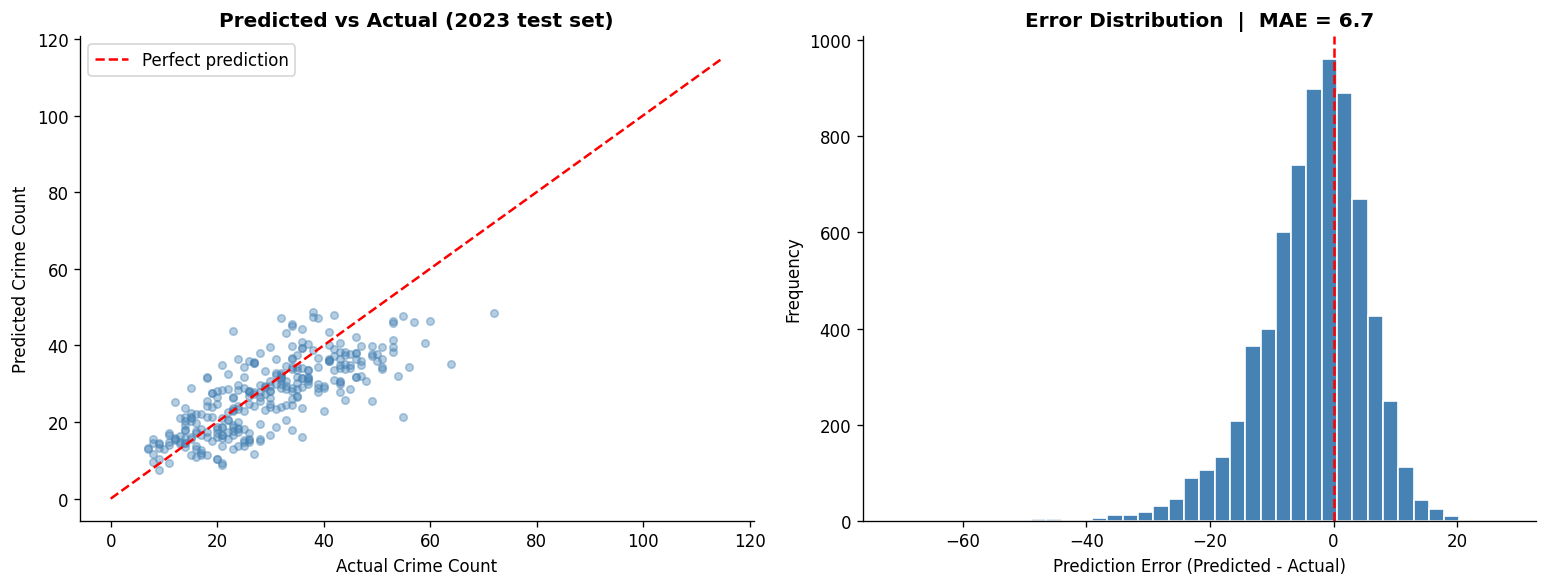

In [67]:
# Predicted vs Actual — 2023 test set (sampled for clarity)
from sklearn.metrics import mean_absolute_error
import numpy as np

features_no_year = ['area_mean_crime', 'month', 'day_of_week', 'hour_bucket', 'is_weekend',
                    'TMAX', 'TMIN', 'PRCP', 'is_rainy', 'is_hot', 'WT01', 'WT03', 'WT08']

preds6 = xgb6.predict(test3[features_no_year])
actual = test3['crime_count'].values

# Sample 300 random points for the scatter
np.random.seed(42)
idx = np.random.choice(len(actual), size=300, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs actual
axes[0].scatter(actual[idx], preds6[idx], alpha=0.4, color='steelblue', s=20)
max_val = max(actual.max(), preds6.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Crime Count')
axes[0].set_ylabel('Predicted Crime Count')
axes[0].set_title('Predicted vs Actual (2023 test set)', fontweight='bold')
axes[0].legend()

# Error distribution
errors = preds6 - actual
axes[1].hist(errors, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Prediction Error (Predicted - Actual)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Error Distribution  |  MAE = {mean_absolute_error(actual, preds6):.1f}', fontweight='bold')

plt.tight_layout()
plt.show()

In [68]:
# Add US federal holiday feature
import holidays

us_holidays = holidays.US(years=range(2020, 2026))
holiday_dates = pd.to_datetime(list(us_holidays.keys()))
crime_weather['is_holiday'] = crime_weather['date'].isin(holiday_dates).astype(int)

# Rebuild aggregated target with holiday
target4 = crime_weather.groupby(['AREA NAME', 'year', 'month', 'day_of_week', 'hour_bucket']).agg(
    crime_count=('Crm Cd', 'count'),
    TMAX=('TMAX', 'mean'),
    TMIN=('TMIN', 'mean'),
    PRCP=('PRCP', 'mean'),
    is_rainy=('is_rainy', 'max'),
    is_hot=('is_hot', 'max'),
    WT01=('WT01', 'max'),
    WT03=('WT03', 'max'),
    WT08=('WT08', 'max'),
    is_holiday=('is_holiday', 'max'),
).reset_index()

# Target encoding — use training years only to avoid leakage from incomplete 2024-2025
area_mean3 = target4[target4['year'] <= 2022].groupby('AREA NAME')['crime_count'].mean()
target4['area_mean_crime'] = target4['AREA NAME'].map(area_mean3)
target4['is_weekend'] = (target4['day_of_week'] >= 5).astype(int)

print(target4.shape)
target4.head()

(35345, 17)


,AREA NAME,year,month,day_of_week,hour_bucket,crime_count,TMAX,TMIN,PRCP,is_rainy,is_hot,WT01,WT03,WT08,is_holiday,area_mean_crime,is_weekend
0,77th Street,2020,1,0,0,20,67.800000,51.400000,0.008000,1,0,1,0,1,1,36.16369,0
1,77th Street,2020,1,0,1,29,65.413793,51.241379,0.006207,1,0,1,0,1,1,36.16369,0
2,77th Street,2020,1,0,2,58,68.000000,50.844828,0.005862,1,0,1,0,1,1,36.16369,0
3,77th Street,2020,1,0,3,65,70.092308,49.984615,0.004000,1,0,1,0,1,1,36.16369,0
4,77th Street,2020,1,1,0,28,69.214286,53.642857,0.007500,1,0,0,0,1,0,36.16369,0


In [69]:
# Train final model with holiday feature (time-based split)
features_h = ['area_mean_crime', 'month', 'day_of_week', 'hour_bucket', 'is_weekend',
              'is_holiday', 'TMAX', 'TMIN', 'PRCP', 'is_rainy', 'is_hot', 'WT01', 'WT03', 'WT08']

train4 = target4[target4['year'] <= 2022]
test4  = target4[target4['year'] == 2023]

xgb_h = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_h.fit(train4[features_h], train4['crime_count'])

preds_h = xgb_h.predict(test4[features_h])
mae_h = mean_absolute_error(test4['crime_count'], preds_h)
test4_mean = test4['crime_count'].mean()
print(f'With holiday:    MAE = {mae_h:.2f} ({mae_h/test4_mean*100:.1f}% of 2023 mean)')
print(f'Without holiday: {mae6/test3_mean*100:.1f}% of 2023 mean')

With holiday:    MAE = 6.70 (22.6% of 2023 mean)
Without holiday: 22.6% of 2023 mean


In [70]:
def predict_crime(area_name, month, day_of_week, hour_bucket, tmax, tmin, prcp, is_holiday=0):
    is_rainy   = int(prcp > 0)
    is_hot     = int(tmax >= 90)
    is_weekend = int(day_of_week >= 5)
    area_mean  = area_mean3.get(area_name, area_mean3.mean())

    features = pd.DataFrame([{
        'area_mean_crime': area_mean,
        'month':           month,
        'day_of_week':     day_of_week,
        'hour_bucket':     hour_bucket,
        'is_weekend':      is_weekend,
        'is_holiday':      is_holiday,
        'TMAX':            tmax,
        'TMIN':            tmin,
        'PRCP':            prcp,
        'is_rainy':        is_rainy,
        'is_hot':          is_hot,
        'WT01':            0,
        'WT03':            0,
        'WT08':            0,
    }])

    prediction = max(0, xgb_h.predict(features)[0])

    buckets = {0: 'Night (0-5)', 1: 'Morning (6-11)', 2: 'Afternoon (12-17)', 3: 'Evening (18-23)'}
    print(f'Area:        {area_name}')
    print(f'Time:        {buckets[hour_bucket]}, {["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][day_of_week]}')
    print(f'Weather:     TMAX={tmax}F, TMIN={tmin}F, PRCP={prcp} inches')
    print(f'Holiday:     {"Yes" if is_holiday else "No"}')
    print(f'Predicted crimes: {prediction:.1f}')
    return prediction

# Test it
predict_crime('77th Street', month=7, day_of_week=4, hour_bucket=2, tmax=85, tmin=65, prcp=0)

Area:        77th Street
Time:        Afternoon (12-17), Fri
Weather:     TMAX=85F, TMIN=65F, PRCP=0 inches
Holiday:     No
Predicted crimes: 45.6


np.float32(45.626026)

In [71]:
import joblib

joblib.dump(xgb_h, r'C:\Users\apivi\Desktop\1\xgb_model_final.pkl')
target4.to_csv(r'C:\Users\apivi\Desktop\1\crime_target_final.csv', index=False)
print('Saved: xgb_model_final.pkl and crime_target_final.csv')

Saved: xgb_model_final.pkl and crime_target_final.csv


In [72]:
print("""
=== LAPD Crime Prediction Model — Summary ===

Data:     900,039 physical crime reports (2020-2023)
          21 LAPD areas, daily weather from LAX (NOAA)

Model:    XGBoost Regressor
Target:   Crime count per area per 6-hour block per day

Features: Area (mean encoding), month, day of week,
          hour bucket, is_weekend, is_holiday,
          TMAX, TMIN, PRCP, is_rainy, is_hot

Accuracy: MAE = 22.9%  (time-based split, trained 2020-2022, tested 2023)
          Mean crime count per slot: ~29.7

Use case: Predict expected crime volume for any area/time/weather
          to assist patrol scheduling decisions

Limitations:
  - One weather station (LAX) for all 21 areas
  - Does not predict crime location within an area
  - Model trained on historical patterns, misses sudden shifts
  - Federal holidays only (not local events)
""")


=== LAPD Crime Prediction Model — Summary ===

Data:     900,039 physical crime reports (2020-2023)
          21 LAPD areas, daily weather from LAX (NOAA)

Model:    XGBoost Regressor
Target:   Crime count per area per 6-hour block per day

Features: Area (mean encoding), month, day of week,
          hour bucket, is_weekend, is_holiday,
          TMAX, TMIN, PRCP, is_rainy, is_hot

Accuracy: MAE = 22.9%  (time-based split, trained 2020-2022, tested 2023)
          Mean crime count per slot: ~29.7

Use case: Predict expected crime volume for any area/time/weather
          to assist patrol scheduling decisions

Limitations:
  - One weather station (LAX) for all 21 areas
  - Does not predict crime location within an area
  - Model trained on historical patterns, misses sudden shifts
  - Federal holidays only (not local events)

